In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

In [2]:
iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [3]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(df)

In [5]:
from sklearn.ensemble import IsolationForest

In [6]:
model = IsolationForest(
    contamination=0.05,
    random_state=42
)

predictions = model.fit_predict(X)

In [7]:
df["Anomaly"] = predictions

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Anomaly
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


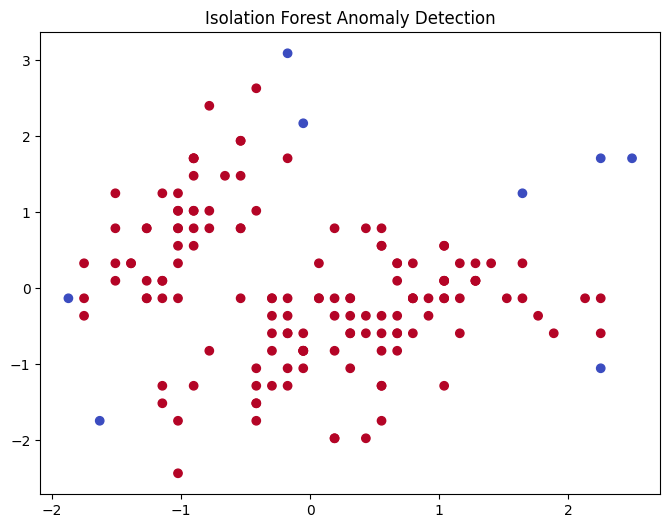

In [8]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=predictions,
    cmap="coolwarm"
)

plt.title(
    "Isolation Forest Anomaly Detection"
)

plt.show()

In [9]:
anomaly_scores = model.decision_function(X)

anomaly_scores[:10]

array([0.18307899, 0.1570891 , 0.13657562, 0.12772209, 0.17206405,
       0.08494536, 0.09346845, 0.18714745, 0.08328268, 0.11894281])

In [10]:
df[df["Anomaly"] == -1]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Anomaly
13,4.3,3.0,1.1,0.1,-1
14,5.8,4.0,1.2,0.2,-1
15,5.7,4.4,1.5,0.4,-1
41,4.5,2.3,1.3,0.3,-1
109,7.2,3.6,6.1,2.5,-1
117,7.7,3.8,6.7,2.2,-1
118,7.7,2.6,6.9,2.3,-1
131,7.9,3.8,6.4,2.0,-1
